# EfficientNet-B0 (K-Fold)

In [5]:
# --- Kaggle Setup: Download ADNI dataset from Google Drive ---

import os, subprocess
from pathlib import Path

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')
ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'

if not os.path.exists(WORK_DIR / 'CN'):
    print('Step 1/3: Installing gdown...')
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown

    print('Step 2/3: Downloading ADNI dataset from Google Drive...')
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)

    print('Step 3/3: Extracting ADNI Dataset...')
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink()
    print('Done. ADNI Dataset ready.')

ADNI_DIR = str(WORK_DIR)
for root, dirs, files in os.walk(WORK_DIR):
    if 'CN' in dirs and 'MCI' in dirs and 'AD' in dirs:
        ADNI_DIR = root
        break

print(f"ADNI_DIR = {ADNI_DIR}")

Step 1/3: Installing gdown...
Step 2/3: Downloading ADNI dataset from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz
From (redirected): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz&confirm=t&uuid=849a4324-d1e7-4cb3-b1f7-99017a008dab
To: /kaggle/working/adni_dataset.zip
100%|██████████| 387M/387M [00:04<00:00, 88.4MB/s] 


Step 3/3: Extracting ADNI Dataset...
Done. ADNI Dataset ready.
ADNI_DIR = /kaggle/working/adni_nifti_preprocessed


In [6]:
import csv
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [7]:
DATA_ROOT  = ADNI_DIR
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_DIR   = "/kaggle/working/checkpoints_effnet"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE   = 224
N_FOLDS      = 5
TEST_RATIO   = 0.15

BATCH_SIZE   = 24
NUM_EPOCHS   = 55

HEAD_HIDDEN    = 192
HEAD_DROPOUT   = 0.50

ADAMW_LR          = 5e-4
ADAMW_WEIGHT_DECAY = 0.04
WARMUP_EPOCHS     = 4

LABEL_SMOOTHING = 0.12

GRAD_CLIP_NORM      = 1.0
VAL_LOSS_EMA_ALPHA  = 0.22

SWA_EPOCHS       = 2
SWA_LR_FACTOR    = 0.08

PATIENCE     = 16

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = [c for c in ['AD', 'CN', 'MCI'] if os.path.isdir(os.path.join(DATA_ROOT, c))]
print(f"Classes found: {CLASS_NAMES}")
print(f"Train: AdamW lr={ADAMW_LR} wd={ADAMW_WEIGHT_DECAY}, warmup={WARMUP_EPOCHS}, clip={GRAD_CLIP_NORM}, "
      f"ema_alpha={VAL_LOSS_EMA_ALPHA}, label_smoothing={LABEL_SMOOTHING}, "
      f"HEAD={HEAD_HIDDEN} do={HEAD_DROPOUT}, SWA={SWA_EPOCHS}x*{SWA_LR_FACTOR}, BATCH={BATCH_SIZE}, patience={PATIENCE}")

Classes found: ['AD', 'CN', 'MCI']
Train: AdamW lr=0.0005 wd=0.04, warmup=4, clip=1.0, ema_alpha=0.22, label_smoothing=0.12, HEAD=192 do=0.5, SWA=2x*0.08, BATCH=24, patience=16


In [8]:
patient_classes = defaultdict(set)
patient_slices  = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f"[WARNING] Missing class folder: {cls_dir}")
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")

leakage_patients = {
    pid: classes
    for pid, classes in patient_classes.items()
    if len(classes) > 1
}

print("\n" + "="*55)
print("  LEAKAGE CHECK")
print("="*55)
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
    for pid, classes in sorted(leakage_patients.items()):
        print(f"    {pid}  ->  {sorted(classes)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {
    pid: list(classes)[0]
    for pid, classes in patient_classes.items()
    if pid not in leakage_patients
}
print(f"\n  Patients kept    : {len(clean_patients)}")
print(f"  Patients excluded: {len(leakage_patients)}")

Total unique patients: 320

  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


In [9]:
class_patients = defaultdict(list)
for pid, cls in clean_patients.items():
    class_patients[cls].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(class_patients[cls])

test_patients     = []
trainval_patients = []

print("="*55)
print("  HOLD-OUT TEST SET (stratified by class)")
print("="*55)

for cls in CLASS_NAMES:
    pids   = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test])
    trainval_patients.extend(pids[n_test:])
    print(f"  {cls}: {len(pids)} total  |  test={n_test}  |  train+val pool={len(pids)-n_test}")

assert not (set(test_patients) & set(trainval_patients)), "Test/trainval overlap!"
print(f"\n  Test patients     : {len(test_patients)}")
print(f"  Train+Val patients: {len(trainval_patients)}")
print(f"  Total             : {len(test_patients)+len(trainval_patients)}")

test_entries = []
for pid in test_patients:
    cls   = clean_patients[pid]
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        test_entries.append((path, label, pid))

print(f"  Test slices       : {len(test_entries)}")

  HOLD-OUT TEST SET (stratified by class)
  AD: 54 total  |  test=8  |  train+val pool=46
  CN: 88 total  |  test=13  |  train+val pool=75
  MCI: 178 total  |  test=26  |  train+val pool=152

  Test patients     : 47
  Train+Val patients: 273
  Total             : 320
  Test slices       : 1247


In [10]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc="Saving"):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base  = os.path.splitext(os.path.basename(path))[0]
        key   = f"{pid}_{base}"
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix   = f"_dup{fname_counts[key]}" if fname_counts[key] > 1 else ""
        out_path = os.path.join(out_dir, f"{key}{suffix}.pt")

        if not os.path.exists(out_path):
            img    = Image.open(path).convert("L")
            img    = img.resize((IMAGE_SIZE, IMAGE_SIZE))
            tensor = transforms.ToTensor()(img)
            tensor = (tensor * 255).byte().repeat(3, 1, 1)
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc="Preprocessing all slices")
print(f"Done. {len(all_entries)} slices saved to {OUTPUT_DIR}")

pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            stem = fname[:-3]
            pt_lookup[stem] = os.path.join(cls_dir, fname)

print(f"pt_lookup built: {len(pt_lookup)} entries")

Preprocessing all slices: 100%|██████████| 8512/8512 [00:19<00:00, 439.91it/s]

Done. 8512 slices saved to /kaggle/working/preprocessed
pt_lookup built: 8512 entries


In [11]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
])

class SliceDataset(Dataset):
    def __init__(self, entries, augment=False):
        self.samples = []
        self.augment = augment
        for path, label, pid in entries:
            base = os.path.splitext(os.path.basename(path))[0]
            key  = f"{pid}_{base}"

            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                found = False
                for dup_idx in range(2, 50):
                    dup_key = f"{key}_dup{dup_idx}"
                    if dup_key in pt_lookup:
                        self.samples.append((pt_lookup[dup_key], label, pid))
                        found = True
                        break
                if not found:
                    pass

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        tensor = torch.load(pt_path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label, pid

    def get_labels(self):
        return [s[1] for s in self.samples]

print("SliceDataset ready.")

SliceDataset ready.


In [12]:
def build_efficientnet_b0_binary():
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, HEAD_HIDDEN),
        nn.ReLU(inplace=True),
        nn.Dropout(p=HEAD_DROPOUT),
        nn.Linear(HEAD_HIDDEN, 2),
    )
    for m in model.classifier.modules():
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            nn.init.zeros_(m.bias)

    for p in model.features.parameters():
        p.requires_grad = False

    n_head = sum(p.numel() for p in model.classifier.parameters())
    n_back = sum(p.numel() for p in model.features.parameters())
    print(f"Backbone params (frozen): {n_back:,} | Classifier params (trainable): {n_head:,}")
    return model

m = build_efficientnet_b0_binary()
print("EfficientNet-B0 (binary, frozen backbone) ready.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338
EfficientNet-B0 (binary, frozen backbone) ready.


In [13]:
def set_train_head_only(model, train_state: bool):
    """model.eval() freezes backbone BatchNorm running stats; only classifier trains."""
    if train_state:
        model.eval()
        model.classifier.train()
    else:
        model.eval()

def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc="", head_only_train=False):
    is_train = optimizer is not None
    if is_train:
        set_train_head_only(model, head_only_train)
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for images, labels, _ in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda" if device.type == 'cuda' else "cpu"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                if scaler.is_enabled():
                    scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.classifier.parameters(), max_norm=GRAD_CLIP_NORM
                )
                scaler.step(optimizer)
                scaler.update()

            correct += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)

def patient_level_eval(loader, model, threshold=0.5):
    model.eval()
    patient_probs = defaultdict(list)
    patient_labels = {}

    with torch.no_grad():
        for images, labels, pids in tqdm(loader, desc="Patient-eval", leave=False):
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda" if device.type == 'cuda' else "cpu"):
                logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            for prob, label, pid in zip(probs, labels.numpy(), pids):
                patient_probs[pid].append(prob)
                patient_labels[pid] = int(label)

    all_true, all_pred = [], []
    for pid, probs_list in patient_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        pos_prob = float(avg_prob[1])
        pred_label = 1 if pos_prob >= threshold else 0
        all_true.append(patient_labels[pid])
        all_pred.append(pred_label)

    acc = float(np.mean(np.array(all_true) == np.array(all_pred))) if all_true else 0.0
    return acc, all_true, all_pred

def optimize_threshold(loader, model):
    model.eval()
    patient_probs = defaultdict(list)
    patient_labels = {}

    with torch.no_grad():
        for images, labels, pids in loader:
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast(device_type="cuda" if device.type == 'cuda' else "cpu"):
                logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            for prob, label, pid in zip(probs, labels.numpy(), pids):
                patient_probs[pid].append(prob)
                patient_labels[pid] = int(label)

    pids_list = list(patient_probs.keys())
    avg_pos_probs = np.array([np.mean(patient_probs[p], axis=0)[1] for p in pids_list]) if pids_list else np.array([])
    true_labels = np.array([patient_labels[p] for p in pids_list]) if pids_list else np.array([])

    best_thresh, best_f1 = 0.5, 0.0
    for thresh in np.arange(0.05, 0.95, 0.01):
        if avg_pos_probs.size == 0:
            break
        preds = (avg_pos_probs >= thresh).astype(int)
        tp = int(((preds == 1) & (true_labels == 1)).sum())
        fp = int(((preds == 1) & (true_labels == 0)).sum())
        fn = int(((preds == 0) & (true_labels == 1)).sum())
        if tp + fp == 0 or tp + fn == 0:
            continue
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        if precision + recall == 0:
            continue
        f1 = 2 * precision * recall / (precision + recall)
        if f1 > best_f1:
            best_f1, best_thresh = float(f1), float(thresh)

    return best_thresh, best_f1

print("Training utilities defined.")

Training utilities defined.



  AD vs REST  —  5-Fold Cross-Validation

  --- Fold 1/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6540 train slice acc=63.0% | val loss=0.7837 val_ema=0.7837 val SLICE acc=41.8%
    Best val loss (EMA)=0.7837 (checkpoint) — saved.


  Ep 02 | train loss=0.5896 train slice acc=71.5% | val loss=0.6051 val_ema=0.7444 val SLICE acc=71.2%
    Best val loss (EMA)=0.7444 (checkpoint) — saved.


  Ep 03 | train loss=0.5509 train slice acc=76.0% | val loss=0.8000 val_ema=0.7566 val SLICE acc=49.9%


  Ep 04 | train loss=0.5206 train slice acc=78.4% | val loss=0.7193 val_ema=0.7484 val SLICE acc=60.1%


...

  Ep 51 | train loss=0.2727 train slice acc=99.3% | val loss=0.5454 val_ema=0.5534 val SLICE acc=77.1%
    Best val loss (EMA)=0.5534 (checkpoint) — saved.


  Ep 52 | train loss=0.2763 train slice acc=99.0% | val loss=0.5558 val_ema=0.5540 val SLICE acc=77.2%


  Ep 53 | train loss=0.2738 train slice acc=99.2% | val loss=0.5554 val_ema=0.5543 val SLICE acc=78.3%


  Ep 54 | train loss=0.2739 train slice acc=99.1% | val loss=0.5450 val_ema=0.5522 val SLICE acc=78.8%
    Best val loss (EMA)=0.5522 (checkpoint) — saved.


  Ep 55 | train loss=0.2725 train slice acc=99.4% | val loss=0.5612 val_ema=0.5542 val SLICE acc=79.3%
    SWA: 2 extra epochs at lr=0.000010


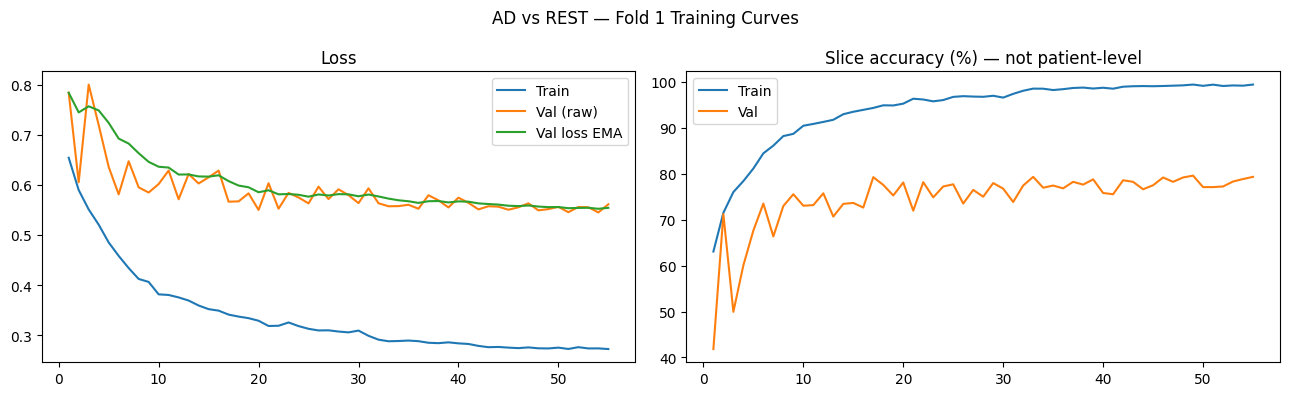

  Fold 1 — Val SLICE acc on best checkpoint: 78.14%
  Fold 1 — Optimal threshold: 0.21 (target-class F1=0.545)


  Fold 1 — Patient-level val acc (@thresh=0.21): 73.21%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 2/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6520 train slice acc=64.0% | val loss=0.6824 val_ema=0.6824 val SLICE acc=54.1%
    Best val loss (EMA)=0.6824 (checkpoint) — saved.


  Ep 02 | train loss=0.5975 train slice acc=70.4% | val loss=0.6309 val_ema=0.6711 val SLICE acc=64.4%
    Best val loss (EMA)=0.6711 (checkpoint) — saved.


  Ep 03 | train loss=0.5465 train slice acc=75.8% | val loss=0.7186 val_ema=0.6815 val SLICE acc=59.9%


...

  Ep 51 | train loss=0.2767 train slice acc=98.9% | val loss=0.6002 val_ema=0.6030 val SLICE acc=76.5%
    Best val loss (EMA)=0.6030 (checkpoint) — saved.


  Ep 52 | train loss=0.2776 train slice acc=98.9% | val loss=0.6010 val_ema=0.6026 val SLICE acc=77.3%
    Best val loss (EMA)=0.6026 (checkpoint) — saved.


  Ep 53 | train loss=0.2775 train slice acc=98.9% | val loss=0.5952 val_ema=0.6010 val SLICE acc=77.8%
    Best val loss (EMA)=0.6010 (checkpoint) — saved.


  Ep 54 | train loss=0.2775 train slice acc=98.9% | val loss=0.5996 val_ema=0.6007 val SLICE acc=76.4%
    Best val loss (EMA)=0.6007 (checkpoint) — saved.


  Ep 55 | train loss=0.2759 train slice acc=99.0% | val loss=0.5916 val_ema=0.5987 val SLICE acc=77.3%
    Best val loss (EMA)=0.5987 (checkpoint) — saved.
    SWA: 2 extra epochs at lr=0.000010


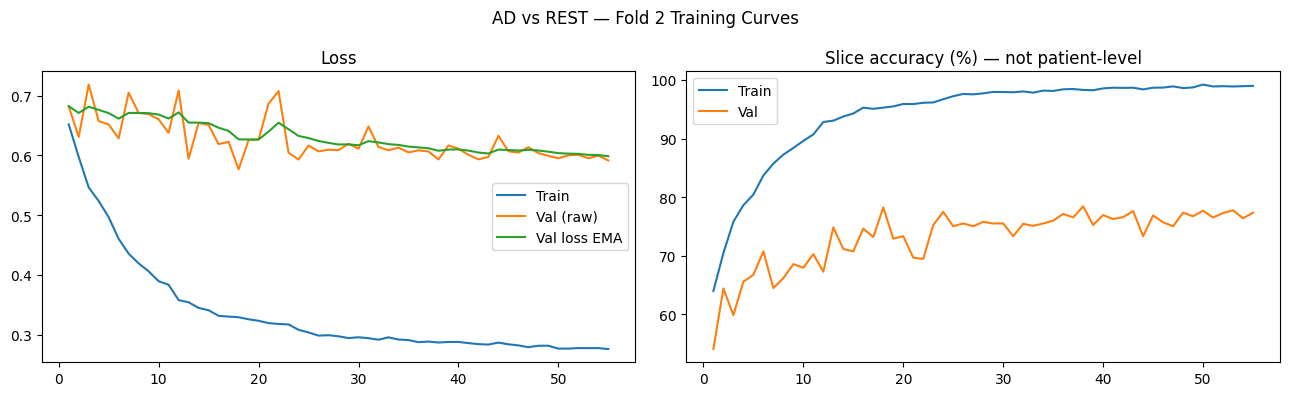

  Fold 2 — Val SLICE acc on best checkpoint: 76.39%
  Fold 2 — Optimal threshold: 0.26 (target-class F1=0.500)


  Fold 2 — Patient-level val acc (@thresh=0.26): 70.91%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 3/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6522 train slice acc=63.5% | val loss=0.6565 val_ema=0.6565 val SLICE acc=59.8%
    Best val loss (EMA)=0.6565 (checkpoint) — saved.


  Ep 02 | train loss=0.5921 train slice acc=71.3% | val loss=0.6347 val_ema=0.6517 val SLICE acc=65.9%
    Best val loss (EMA)=0.6517 (checkpoint) — saved.


  Ep 03 | train loss=0.5342 train slice acc=77.0% | val loss=0.6077 val_ema=0.6421 val SLICE acc=70.0%
    Best val loss (EMA)=0.6421 (checkpoint) — saved.


...

  Ep 51 | train loss=0.2751 train slice acc=99.1% | val loss=0.5823 val_ema=0.5802 val SLICE acc=77.4%


  Ep 52 | train loss=0.2755 train slice acc=99.0% | val loss=0.5623 val_ema=0.5763 val SLICE acc=79.1%
    Best val loss (EMA)=0.5763 (checkpoint) — saved.


  Ep 53 | train loss=0.2731 train slice acc=99.3% | val loss=0.5673 val_ema=0.5743 val SLICE acc=78.0%
    Best val loss (EMA)=0.5743 (checkpoint) — saved.


  Ep 54 | train loss=0.2723 train slice acc=99.2% | val loss=0.5667 val_ema=0.5726 val SLICE acc=78.6%
    Best val loss (EMA)=0.5726 (checkpoint) — saved.


  Ep 55 | train loss=0.2729 train slice acc=99.2% | val loss=0.5773 val_ema=0.5737 val SLICE acc=76.4%
    SWA: 2 extra epochs at lr=0.000010


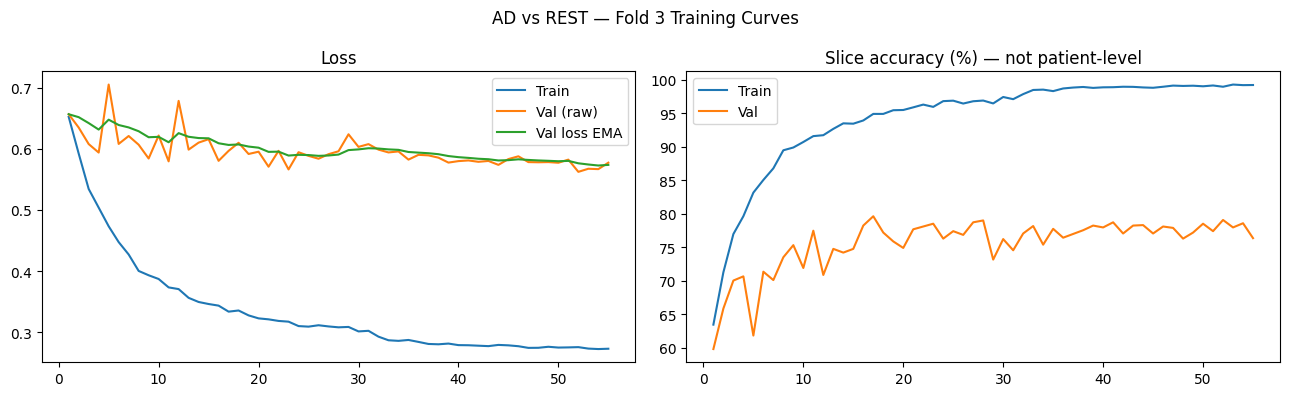

  Fold 3 — Val SLICE acc on best checkpoint: 78.25%
  Fold 3 — Optimal threshold: 0.17 (target-class F1=0.485)


  Fold 3 — Patient-level val acc (@thresh=0.17): 68.52%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 4/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6560 train slice acc=62.1% | val loss=0.7330 val_ema=0.7330 val SLICE acc=52.7%
    Best val loss (EMA)=0.7330 (checkpoint) — saved.


  Ep 02 | train loss=0.5865 train slice acc=71.8% | val loss=0.7281 val_ema=0.7319 val SLICE acc=59.4%
    Best val loss (EMA)=0.7319 (checkpoint) — saved.


  Ep 03 | train loss=0.5469 train slice acc=75.6% | val loss=0.7511 val_ema=0.7361 val SLICE acc=61.1%


...

  Ep 51 | train loss=0.2786 train slice acc=98.9% | val loss=0.5907 val_ema=0.5893 val SLICE acc=77.3%


  Ep 52 | train loss=0.2821 train slice acc=98.6% | val loss=0.5907 val_ema=0.5896 val SLICE acc=76.8%


  Ep 53 | train loss=0.2787 train slice acc=98.9% | val loss=0.5802 val_ema=0.5875 val SLICE acc=77.4%
    Best val loss (EMA)=0.5875 (checkpoint) — saved.


  Ep 54 | train loss=0.2795 train slice acc=98.8% | val loss=0.5798 val_ema=0.5858 val SLICE acc=78.0%
    Best val loss (EMA)=0.5858 (checkpoint) — saved.


  Ep 55 | train loss=0.2777 train slice acc=99.0% | val loss=0.5995 val_ema=0.5889 val SLICE acc=75.7%
    SWA: 2 extra epochs at lr=0.000020


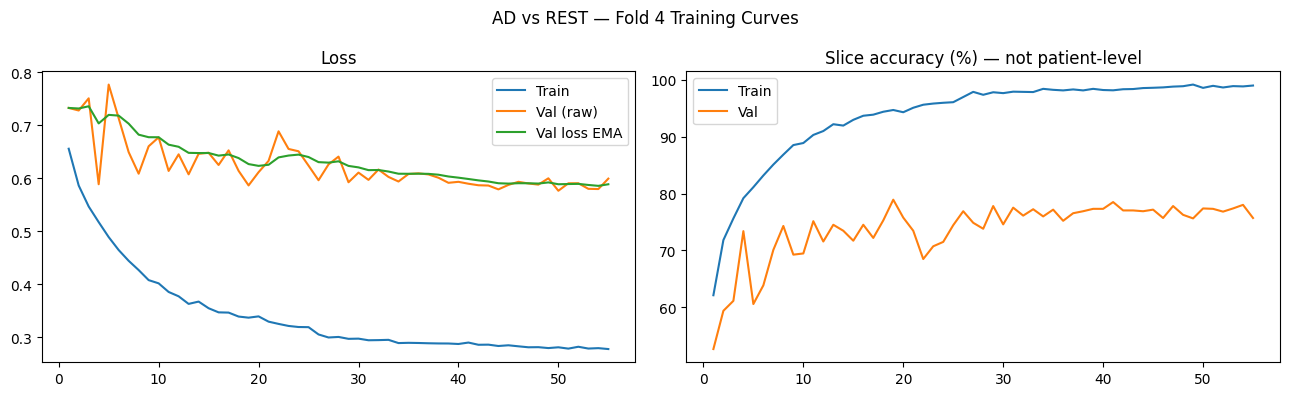

  Fold 4 — Val SLICE acc on best checkpoint: 77.45%
  Fold 4 — Optimal threshold: 0.22 (target-class F1=0.438)


  Fold 4 — Patient-level val acc (@thresh=0.22): 66.67%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 5/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6581 train slice acc=63.0% | val loss=0.6881 val_ema=0.6881 val SLICE acc=56.2%
    Best val loss (EMA)=0.6881 (checkpoint) — saved.


  Ep 02 | train loss=0.5934 train slice acc=70.7% | val loss=0.8763 val_ema=0.7295 val SLICE acc=42.7%


  Ep 03 | train loss=0.5539 train slice acc=75.2% | val loss=0.6603 val_ema=0.7142 val SLICE acc=64.4%


...

  Ep 13 | train loss=0.3769 train slice acc=91.8% | val loss=0.7197 val_ema=0.7227 val SLICE acc=66.3%


  Ep 14 | train loss=0.3689 train slice acc=92.2% | val loss=0.7800 val_ema=0.7353 val SLICE acc=62.3%


  Ep 15 | train loss=0.3566 train slice acc=92.7% | val loss=0.6989 val_ema=0.7273 val SLICE acc=69.8%


  Ep 16 | train loss=0.3359 train slice acc=94.8% | val loss=0.6678 val_ema=0.7142 val SLICE acc=72.8%


  Ep 17 | train loss=0.3285 train slice acc=95.5% | val loss=0.7003 val_ema=0.7112 val SLICE acc=69.9%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000020


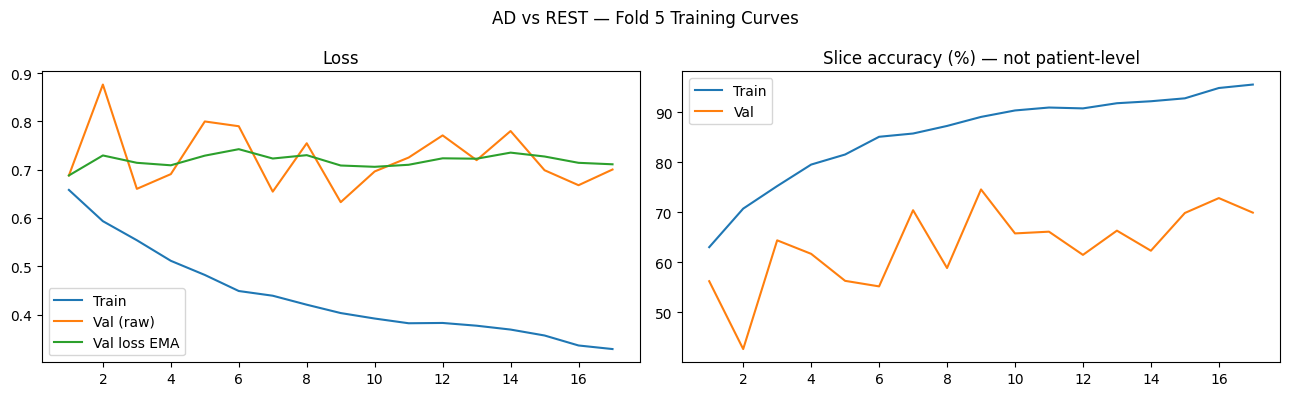

  Fold 5 — Val SLICE acc on best checkpoint: 59.75%
  Fold 5 — Optimal threshold: 0.50 (target-class F1=0.412)


  Fold 5 — Patient-level val acc (@thresh=0.50): 62.96%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  AD vs REST — 5-Fold CV Patient Acc: 68.45% ± 3.52% | Mean threshold: 0.27

  CN vs REST  —  5-Fold Cross-Validation

  --- Fold 1/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6529 train slice acc=63.3% | val loss=0.6473 val_ema=0.6473 val SLICE acc=69.0%
    Best val loss (EMA)=0.6473 (checkpoint) — saved.


  Ep 02 | train loss=0.6054 train slice acc=70.1% | val loss=0.6682 val_ema=0.6519 val SLICE acc=68.9%


  Ep 03 | train loss=0.5961 train slice acc=71.2% | val loss=0.6507 val_ema=0.6516 val SLICE acc=73.2%


...

  Ep 13 | train loss=0.4413 train slice acc=85.4% | val loss=0.8555 val_ema=0.8161 val SLICE acc=68.2%


  Ep 14 | train loss=0.4310 train slice acc=86.4% | val loss=0.8530 val_ema=0.8243 val SLICE acc=66.7%


  Ep 15 | train loss=0.4297 train slice acc=86.9% | val loss=0.8456 val_ema=0.8289 val SLICE acc=68.6%


  Ep 16 | train loss=0.4126 train slice acc=87.9% | val loss=0.8513 val_ema=0.8339 val SLICE acc=64.1%


  Ep 17 | train loss=0.4085 train slice acc=88.6% | val loss=0.8610 val_ema=0.8398 val SLICE acc=64.4%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000010


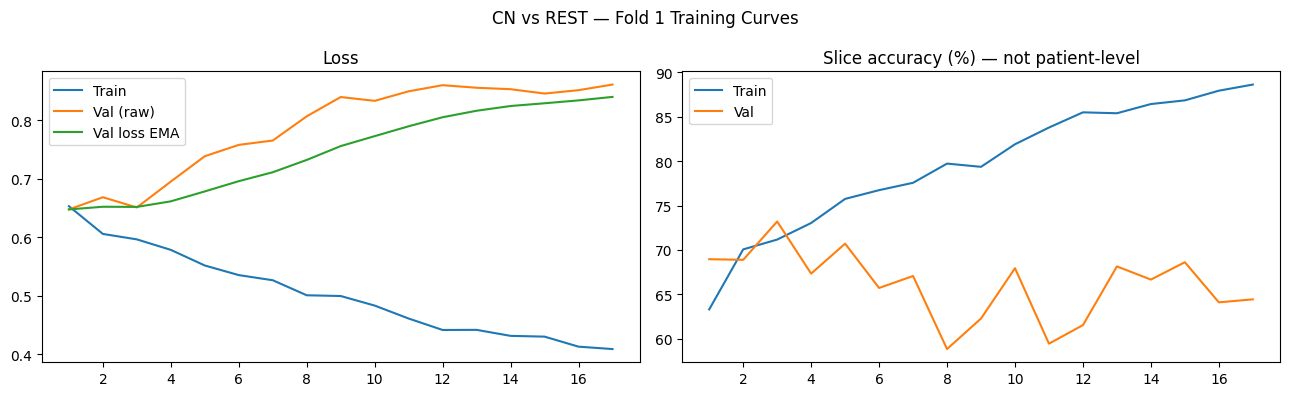

  Fold 1 — Val SLICE acc on best checkpoint: 62.15%
  Fold 1 — Optimal threshold: 0.38 (target-class F1=0.444)


  Fold 1 — Patient-level val acc (@thresh=0.38): 46.43%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 2/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6641 train slice acc=61.8% | val loss=0.6290 val_ema=0.6290 val SLICE acc=69.2%
    Best val loss (EMA)=0.6290 (checkpoint) — saved.


  Ep 02 | train loss=0.6210 train slice acc=67.1% | val loss=0.6704 val_ema=0.6381 val SLICE acc=61.8%


  Ep 03 | train loss=0.5946 train slice acc=70.6% | val loss=0.6756 val_ema=0.6463 val SLICE acc=61.2%


...

  Ep 13 | train loss=0.4267 train slice acc=86.6% | val loss=0.7620 val_ema=0.7076 val SLICE acc=62.9%


  Ep 14 | train loss=0.4282 train slice acc=87.7% | val loss=0.7238 val_ema=0.7112 val SLICE acc=67.0%


  Ep 15 | train loss=0.4105 train slice acc=88.9% | val loss=0.7019 val_ema=0.7091 val SLICE acc=69.0%


  Ep 16 | train loss=0.4066 train slice acc=88.8% | val loss=0.7298 val_ema=0.7137 val SLICE acc=66.2%


  Ep 17 | train loss=0.4009 train slice acc=89.3% | val loss=0.7373 val_ema=0.7189 val SLICE acc=63.9%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000010


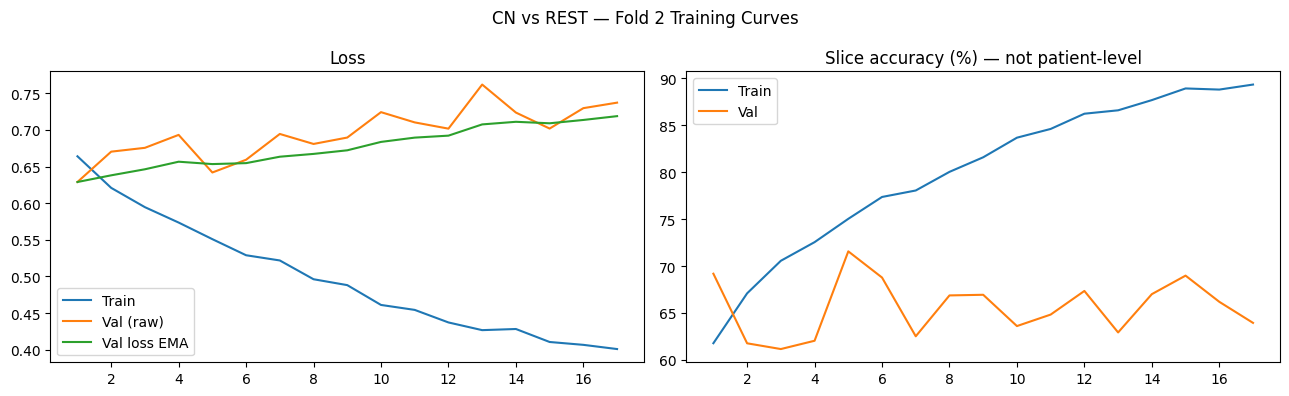

  Fold 2 — Val SLICE acc on best checkpoint: 71.29%
  Fold 2 — Optimal threshold: 0.46 (target-class F1=0.611)


  Fold 2 — Patient-level val acc (@thresh=0.46): 74.55%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 3/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6610 train slice acc=62.4% | val loss=0.6180 val_ema=0.6180 val SLICE acc=71.2%
    Best val loss (EMA)=0.6180 (checkpoint) — saved.


  Ep 02 | train loss=0.6169 train slice acc=67.7% | val loss=0.6454 val_ema=0.6240 val SLICE acc=63.9%


  Ep 03 | train loss=0.5843 train slice acc=72.2% | val loss=0.6132 val_ema=0.6216 val SLICE acc=70.0%


...

  Ep 13 | train loss=0.4098 train slice acc=88.4% | val loss=0.7910 val_ema=0.7456 val SLICE acc=63.7%


  Ep 14 | train loss=0.4116 train slice acc=88.6% | val loss=0.7503 val_ema=0.7466 val SLICE acc=65.3%


  Ep 15 | train loss=0.4090 train slice acc=88.7% | val loss=0.8108 val_ema=0.7607 val SLICE acc=61.4%


  Ep 16 | train loss=0.3944 train slice acc=89.4% | val loss=0.7705 val_ema=0.7629 val SLICE acc=65.0%


  Ep 17 | train loss=0.3859 train slice acc=90.7% | val loss=0.7950 val_ema=0.7700 val SLICE acc=64.0%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000010


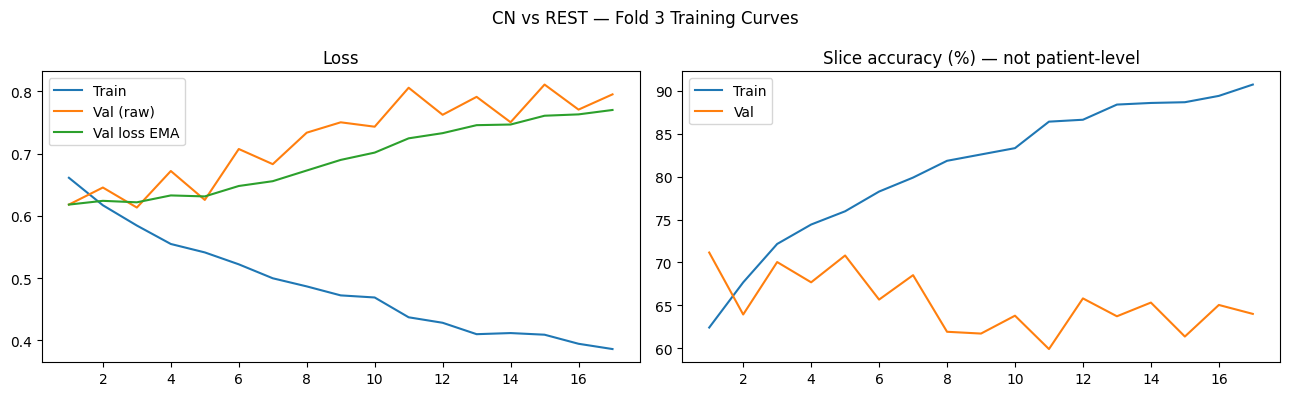

  Fold 3 — Val SLICE acc on best checkpoint: 72.90%
  Fold 3 — Optimal threshold: 0.49 (target-class F1=0.500)


  Fold 3 — Patient-level val acc (@thresh=0.49): 77.78%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 4/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6624 train slice acc=61.8% | val loss=0.5996 val_ema=0.5996 val SLICE acc=68.9%
    Best val loss (EMA)=0.5996 (checkpoint) — saved.


  Ep 02 | train loss=0.6144 train slice acc=68.9% | val loss=0.6211 val_ema=0.6043 val SLICE acc=65.1%


  Ep 03 | train loss=0.5927 train slice acc=71.2% | val loss=0.6432 val_ema=0.6129 val SLICE acc=64.4%


...

  Ep 13 | train loss=0.4370 train slice acc=85.8% | val loss=0.6713 val_ema=0.6550 val SLICE acc=68.6%


  Ep 14 | train loss=0.4217 train slice acc=87.6% | val loss=0.6877 val_ema=0.6622 val SLICE acc=69.7%


  Ep 15 | train loss=0.4254 train slice acc=87.3% | val loss=0.6861 val_ema=0.6675 val SLICE acc=67.5%


  Ep 16 | train loss=0.4094 train slice acc=88.6% | val loss=0.6987 val_ema=0.6743 val SLICE acc=69.0%


  Ep 17 | train loss=0.4000 train slice acc=89.5% | val loss=0.6971 val_ema=0.6793 val SLICE acc=68.2%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000010


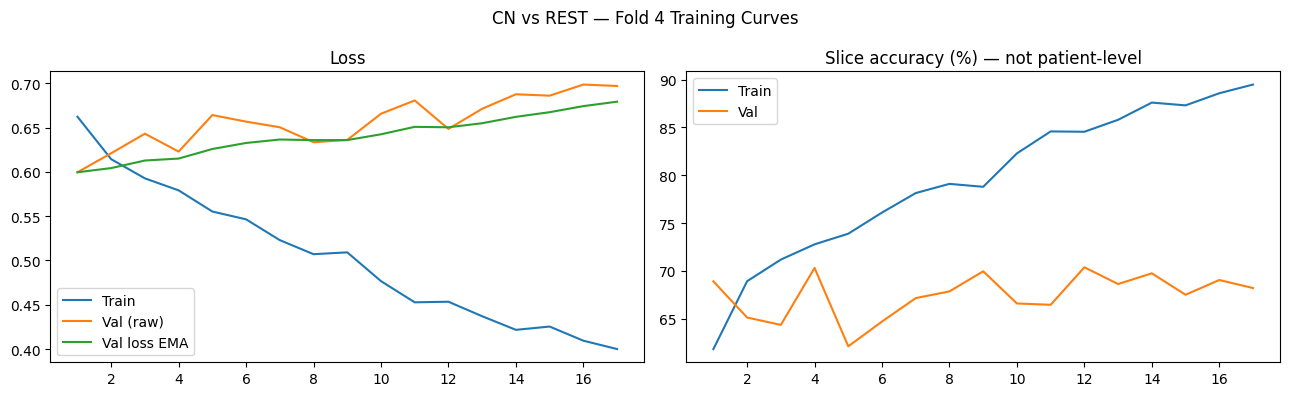

  Fold 4 — Val SLICE acc on best checkpoint: 67.30%
  Fold 4 — Optimal threshold: 0.38 (target-class F1=0.565)


  Fold 4 — Patient-level val acc (@thresh=0.38): 62.96%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 5/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6539 train slice acc=63.3% | val loss=0.6449 val_ema=0.6449 val SLICE acc=65.8%
    Best val loss (EMA)=0.6449 (checkpoint) — saved.


  Ep 02 | train loss=0.6090 train slice acc=68.9% | val loss=0.6309 val_ema=0.6419 val SLICE acc=70.1%
    Best val loss (EMA)=0.6419 (checkpoint) — saved.


  Ep 03 | train loss=0.5899 train slice acc=71.3% | val loss=0.6374 val_ema=0.6409 val SLICE acc=69.3%
    Best val loss (EMA)=0.6409 (checkpoint) — saved.


...

  Ep 15 | train loss=0.4127 train slice acc=88.4% | val loss=0.7537 val_ema=0.7301 val SLICE acc=67.8%


  Ep 16 | train loss=0.4034 train slice acc=89.3% | val loss=0.7561 val_ema=0.7358 val SLICE acc=65.6%


  Ep 17 | train loss=0.3960 train slice acc=90.0% | val loss=0.7473 val_ema=0.7383 val SLICE acc=68.3%


  Ep 18 | train loss=0.3957 train slice acc=89.4% | val loss=0.7468 val_ema=0.7402 val SLICE acc=66.1%


  Ep 19 | train loss=0.3925 train slice acc=90.0% | val loss=0.7457 val_ema=0.7414 val SLICE acc=65.4%
    Early stopping at epoch 19.
    SWA: 2 extra epochs at lr=0.000010


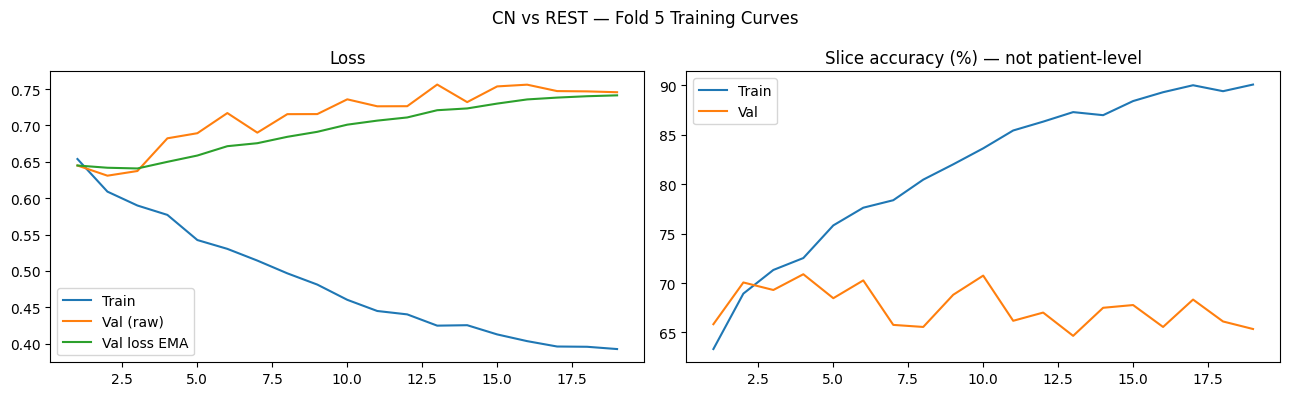

  Fold 5 — Val SLICE acc on best checkpoint: 68.88%
  Fold 5 — Optimal threshold: 0.30 (target-class F1=0.512)


  Fold 5 — Patient-level val acc (@thresh=0.30): 61.11%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  CN vs REST — 5-Fold CV Patient Acc: 64.57% ± 11.11% | Mean threshold: 0.40

  MCI vs REST  —  5-Fold Cross-Validation

  --- Fold 1/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6849 train slice acc=55.3% | val loss=0.6955 val_ema=0.6955 val SLICE acc=54.9%
    Best val loss (EMA)=0.6955 (checkpoint) — saved.


  Ep 02 | train loss=0.6715 train slice acc=58.8% | val loss=0.6934 val_ema=0.6950 val SLICE acc=54.7%
    Best val loss (EMA)=0.6950 (checkpoint) — saved.


  Ep 03 | train loss=0.6457 train slice acc=63.2% | val loss=0.6969 val_ema=0.6954 val SLICE acc=56.3%


...

  Ep 14 | train loss=0.4818 train slice acc=82.4% | val loss=0.8168 val_ema=0.7834 val SLICE acc=57.2%


  Ep 15 | train loss=0.4778 train slice acc=82.2% | val loss=0.8013 val_ema=0.7873 val SLICE acc=54.9%


  Ep 16 | train loss=0.4612 train slice acc=84.2% | val loss=0.8247 val_ema=0.7956 val SLICE acc=57.6%


  Ep 17 | train loss=0.4548 train slice acc=84.7% | val loss=0.7861 val_ema=0.7935 val SLICE acc=59.6%


  Ep 18 | train loss=0.4461 train slice acc=85.8% | val loss=0.8173 val_ema=0.7987 val SLICE acc=60.6%
    Early stopping at epoch 18.
    SWA: 2 extra epochs at lr=0.000010


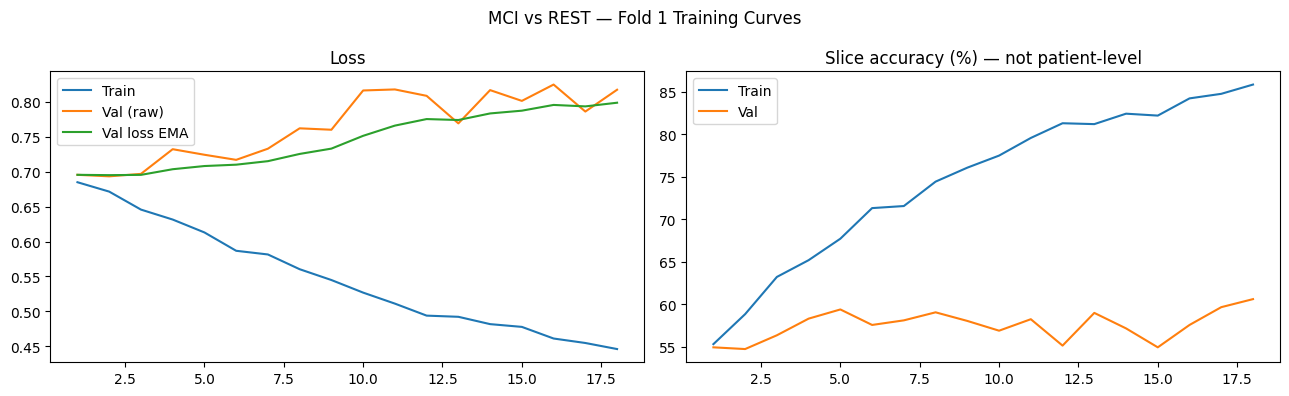

  Fold 1 — Val SLICE acc on best checkpoint: 57.42%
  Fold 1 — Optimal threshold: 0.45 (target-class F1=0.747)


  Fold 1 — Patient-level val acc (@thresh=0.45): 62.50%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 2/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6812 train slice acc=56.4% | val loss=0.7142 val_ema=0.7142 val SLICE acc=47.6%
    Best val loss (EMA)=0.7142 (checkpoint) — saved.


  Ep 02 | train loss=0.6641 train slice acc=60.3% | val loss=0.7148 val_ema=0.7144 val SLICE acc=49.8%


  Ep 03 | train loss=0.6423 train slice acc=64.7% | val loss=0.7354 val_ema=0.7190 val SLICE acc=49.6%


...

  Ep 13 | train loss=0.4842 train slice acc=81.2% | val loss=0.8652 val_ema=0.8354 val SLICE acc=49.5%


  Ep 14 | train loss=0.4739 train slice acc=83.0% | val loss=0.8666 val_ema=0.8423 val SLICE acc=52.2%


  Ep 15 | train loss=0.4742 train slice acc=82.6% | val loss=0.8814 val_ema=0.8509 val SLICE acc=50.6%


  Ep 16 | train loss=0.4521 train slice acc=84.5% | val loss=0.9356 val_ema=0.8695 val SLICE acc=47.7%


  Ep 17 | train loss=0.4482 train slice acc=85.0% | val loss=0.9236 val_ema=0.8814 val SLICE acc=50.8%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000010


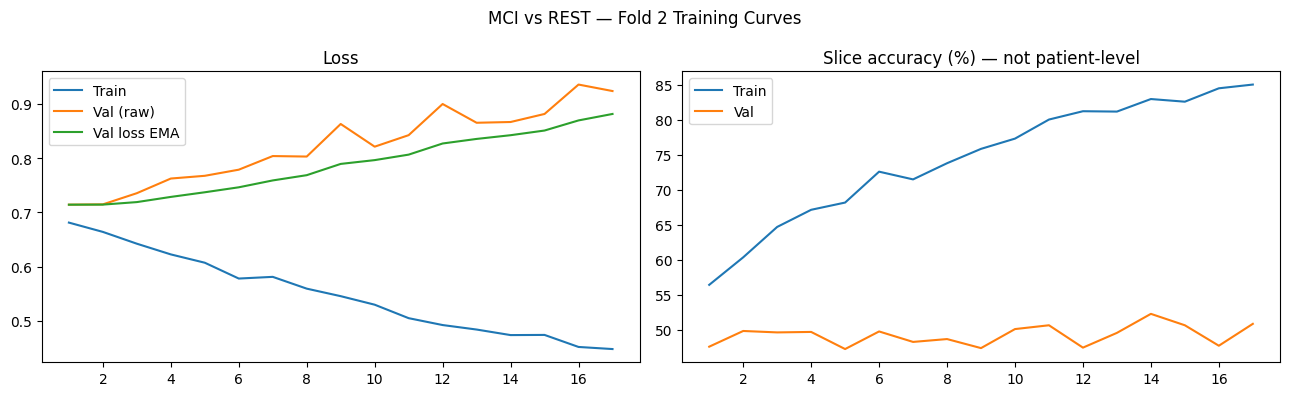

  Fold 2 — Val SLICE acc on best checkpoint: 47.82%
  Fold 2 — Optimal threshold: 0.05 (target-class F1=0.721)


  Fold 2 — Patient-level val acc (@thresh=0.05): 56.36%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 3/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6843 train slice acc=55.7% | val loss=0.7048 val_ema=0.7048 val SLICE acc=47.4%
    Best val loss (EMA)=0.7048 (checkpoint) — saved.


  Ep 02 | train loss=0.6596 train slice acc=62.5% | val loss=0.7227 val_ema=0.7088 val SLICE acc=51.4%


  Ep 03 | train loss=0.6519 train slice acc=63.1% | val loss=0.7040 val_ema=0.7077 val SLICE acc=55.2%


...

  Ep 13 | train loss=0.4666 train slice acc=83.6% | val loss=0.8656 val_ema=0.8279 val SLICE acc=55.4%


  Ep 14 | train loss=0.4638 train slice acc=83.8% | val loss=0.8721 val_ema=0.8376 val SLICE acc=55.2%


  Ep 15 | train loss=0.4578 train slice acc=84.3% | val loss=0.8757 val_ema=0.8460 val SLICE acc=55.7%


  Ep 16 | train loss=0.4414 train slice acc=85.9% | val loss=0.8822 val_ema=0.8539 val SLICE acc=53.4%


  Ep 17 | train loss=0.4273 train slice acc=86.7% | val loss=0.9113 val_ema=0.8666 val SLICE acc=54.5%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000010


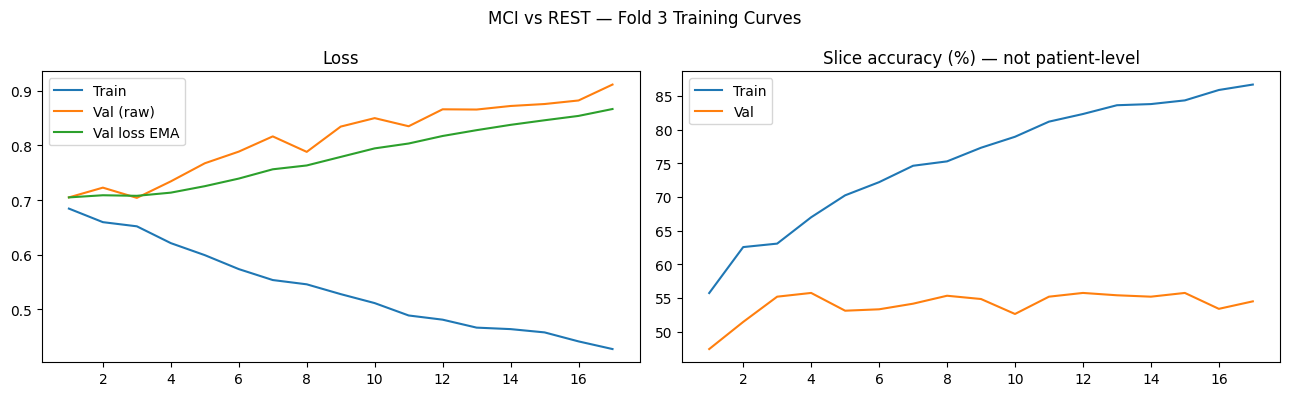

  Fold 3 — Val SLICE acc on best checkpoint: 48.23%
  Fold 3 — Optimal threshold: 0.05 (target-class F1=0.714)


  Fold 3 — Patient-level val acc (@thresh=0.05): 55.56%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 4/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6833 train slice acc=56.1% | val loss=0.6790 val_ema=0.6790 val SLICE acc=55.5%
    Best val loss (EMA)=0.6790 (checkpoint) — saved.


  Ep 02 | train loss=0.6695 train slice acc=59.7% | val loss=0.6772 val_ema=0.6786 val SLICE acc=56.8%
    Best val loss (EMA)=0.6786 (checkpoint) — saved.


  Ep 03 | train loss=0.6508 train slice acc=63.6% | val loss=0.7029 val_ema=0.6839 val SLICE acc=55.2%


...

  Ep 14 | train loss=0.4683 train slice acc=82.8% | val loss=0.7975 val_ema=0.7724 val SLICE acc=54.2%


  Ep 15 | train loss=0.4544 train slice acc=85.3% | val loss=0.8261 val_ema=0.7842 val SLICE acc=52.9%


  Ep 16 | train loss=0.4437 train slice acc=86.1% | val loss=0.8020 val_ema=0.7881 val SLICE acc=55.2%


  Ep 17 | train loss=0.4411 train slice acc=86.2% | val loss=0.8004 val_ema=0.7908 val SLICE acc=54.4%


  Ep 18 | train loss=0.4359 train slice acc=86.7% | val loss=0.8058 val_ema=0.7941 val SLICE acc=53.8%
    Early stopping at epoch 18.
    SWA: 2 extra epochs at lr=0.000010


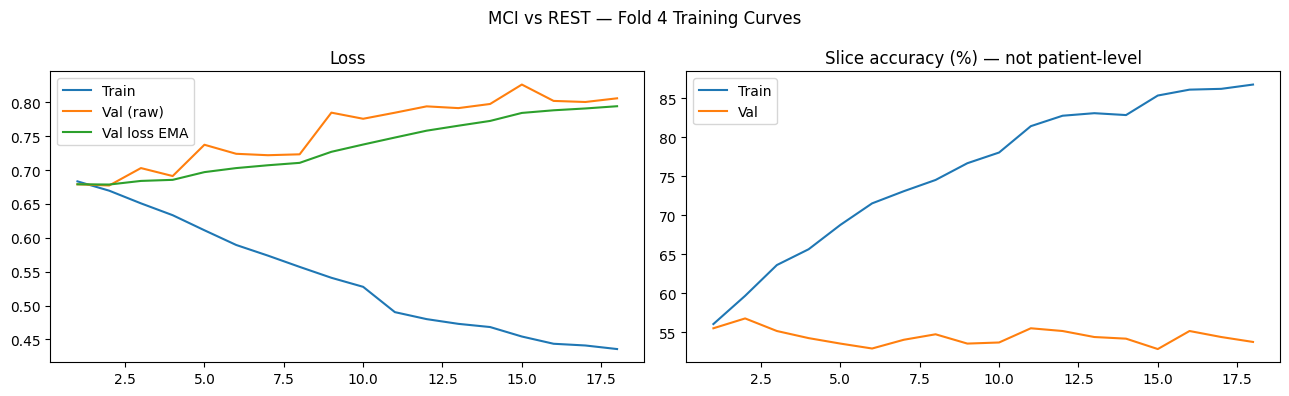

  Fold 4 — Val SLICE acc on best checkpoint: 57.07%
  Fold 4 — Optimal threshold: 0.42 (target-class F1=0.732)


  Fold 4 — Patient-level val acc (@thresh=0.42): 59.26%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  --- Fold 5/5 ---
Backbone params (frozen): 4,007,548 | Classifier params (trainable): 246,338


  Ep 01 | train loss=0.6812 train slice acc=57.2% | val loss=0.7172 val_ema=0.7172 val SLICE acc=46.9%
    Best val loss (EMA)=0.7172 (checkpoint) — saved.


  Ep 02 | train loss=0.6558 train slice acc=62.8% | val loss=0.7310 val_ema=0.7202 val SLICE acc=51.6%


  Ep 03 | train loss=0.6408 train slice acc=64.4% | val loss=0.7685 val_ema=0.7308 val SLICE acc=47.4%


...

  Ep 13 | train loss=0.4628 train slice acc=83.9% | val loss=0.9043 val_ema=0.8630 val SLICE acc=51.8%


  Ep 14 | train loss=0.4554 train slice acc=84.7% | val loss=0.9545 val_ema=0.8831 val SLICE acc=49.6%


  Ep 15 | train loss=0.4555 train slice acc=84.1% | val loss=0.9067 val_ema=0.8883 val SLICE acc=52.0%


  Ep 16 | train loss=0.4277 train slice acc=87.2% | val loss=0.9303 val_ema=0.8975 val SLICE acc=51.8%


  Ep 17 | train loss=0.4340 train slice acc=86.7% | val loss=0.9287 val_ema=0.9044 val SLICE acc=52.0%
    Early stopping at epoch 17.
    SWA: 2 extra epochs at lr=0.000010


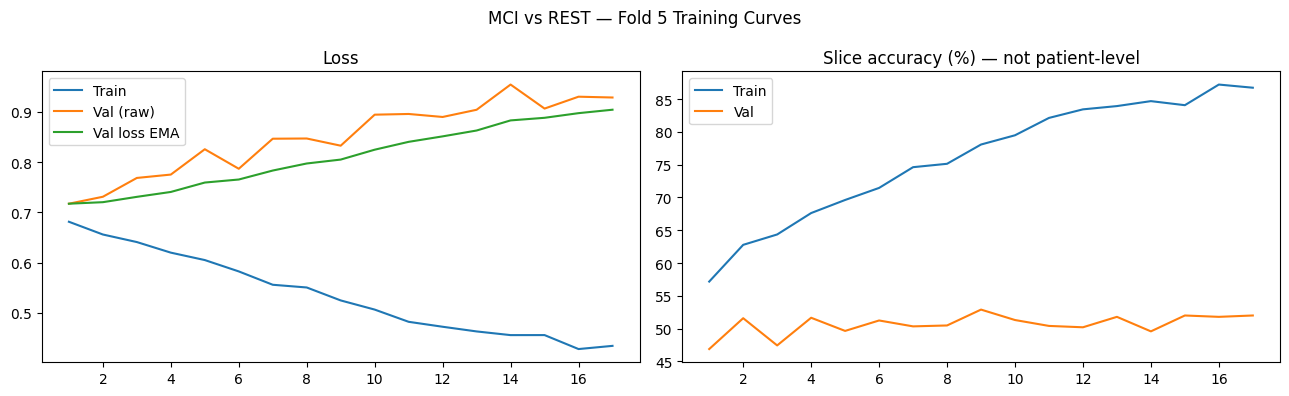

  Fold 5 — Val SLICE acc on best checkpoint: 50.55%
  Fold 5 — Optimal threshold: 0.38 (target-class F1=0.723)


  Fold 5 — Patient-level val acc (@thresh=0.38): 57.41%
           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)

  MCI vs REST — 5-Fold CV Patient Acc: 58.22% ± 2.47% | Mean threshold: 0.27

All folds done.


In [14]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(trainval_by_class[cls])

fold_results = {cls: [] for cls in CLASS_NAMES}
all_fold_models = {cls: [] for cls in CLASS_NAMES}
all_fold_thresholds = {cls: [] for cls in CLASS_NAMES}

def expand(pids):
    out = []
    for pid in pids:
        cls = clean_patients[pid]
        label = CLASS_NAMES.index(cls)
        for path in patient_slices[(pid, cls)]:
            out.append((path, label, pid))
    return out

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print("\n" + "="*65)
    print(f"  {pos_name} vs REST  —  {N_FOLDS}-Fold Cross-Validation")
    print("="*65)

    class_folds = {}
    for cls in CLASS_NAMES:
        pids = trainval_by_class[cls]
        folds = [pids[i::N_FOLDS] for i in range(N_FOLDS)]
        class_folds[cls] = folds

    for fold_idx in range(N_FOLDS):
        print(f"\n  --- Fold {fold_idx+1}/{N_FOLDS} ---")

        val_pids_fold = []
        for cls in CLASS_NAMES:
            val_pids_fold.extend(class_folds[cls][fold_idx])

        train_pids_fold = []
        for cls in CLASS_NAMES:
            for k, chunk in enumerate(class_folds[cls]):
                if k != fold_idx:
                    train_pids_fold.extend(chunk)

        train_entries_fold = expand(train_pids_fold)
        val_entries_fold = expand(val_pids_fold)

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in entries]

        train_bin = binarize(train_entries_fold)
        val_bin = binarize(val_entries_fold)

        train_ds = SliceDataset(train_bin, augment=True)
        val_ds = SliceDataset(val_bin, augment=False)

        train_labels_list = train_ds.get_labels()
        if len(train_labels_list) == 0:
            raise RuntimeError(
                f"Fold {fold_idx+1} ({pos_name}): train_ds is empty. "
                f"Re-run preprocessing step to rebuild cache."
            )

        cls_counts = Counter(train_labels_list)
        weights = [1.0 / cls_counts[l] for l in train_labels_list]
        sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

        train_loader = DataLoader(
            train_ds, batch_size=BATCH_SIZE, sampler=sampler,
            num_workers=4, pin_memory=True, persistent_workers=True
        )
        val_loader = DataLoader(
            val_ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=4, pin_memory=True, persistent_workers=True
        )

        model = build_efficientnet_b0_binary().to(device)

        criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
        optimizer = optim.AdamW(
            model.classifier.parameters(),
            lr=ADAMW_LR,
            weight_decay=ADAMW_WEIGHT_DECAY,
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=4
        )
        scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

        ckpt_path = os.path.join(CKPT_DIR, f"fold{fold_idx+1}_{pos_name}_vs_rest.pt")

        best_val_loss, patience_ctr = float("inf"), 0
        val_loss_ema = None
        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_loss_ema": []}

        for epoch in range(1, NUM_EPOCHS + 1):
            if epoch <= WARMUP_EPOCHS:
                w = epoch / float(WARMUP_EPOCHS)
                for pg in optimizer.param_groups:
                    pg["lr"] = ADAMW_LR * w

            tr_loss, tr_acc = run_epoch(
                train_loader, model, criterion, optimizer, scaler,
                desc=f"Ep{epoch}/{NUM_EPOCHS} [train]", head_only_train=True,
            )
            vl_loss, vl_acc = run_epoch(
                val_loader, model, criterion, desc=f"Ep{epoch}/{NUM_EPOCHS} [val]",
            )

            if val_loss_ema is None:
                val_loss_ema = float(vl_loss)
            else:
                a = VAL_LOSS_EMA_ALPHA
                val_loss_ema = (1.0 - a) * val_loss_ema + a * float(vl_loss)

            history["train_loss"].append(tr_loss)
            history["train_acc"].append(tr_acc)
            history["val_loss"].append(vl_loss)
            history["val_acc"].append(vl_acc)
            history["val_loss_ema"].append(val_loss_ema)

            if epoch > WARMUP_EPOCHS:
                scheduler.step(val_loss_ema)
            print(f"  Ep {epoch:02d} | train loss={tr_loss:.4f} train slice acc={tr_acc*100:.1f}% | "
                  f"val loss={vl_loss:.4f} val_ema={val_loss_ema:.4f} val SLICE acc={vl_acc*100:.1f}%")

            if val_loss_ema < best_val_loss - 1e-5:
                best_val_loss = val_loss_ema
                torch.save(model.state_dict(), ckpt_path)
                patience_ctr = 0
                print(f"    Best val loss (EMA)={best_val_loss:.4f} (checkpoint) — saved.")
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    print(f"    Early stopping at epoch {epoch}.")
                    break

        from torch.optim.swa_utils import AveragedModel

        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        swa_model = AveragedModel(model)
        swa_lr = max(1e-5, float(optimizer.param_groups[0]["lr"]) * SWA_LR_FACTOR)
        swa_optimizer = optim.AdamW(
            model.classifier.parameters(),
            lr=swa_lr,
            weight_decay=ADAMW_WEIGHT_DECAY,
        )
        print(f"    SWA: {SWA_EPOCHS} extra epochs at lr={swa_lr:.6f}")
        for _ in range(SWA_EPOCHS):
            run_epoch(
                train_loader, model, criterion, swa_optimizer, scaler,
                desc="SWA train", head_only_train=True,
            )
            swa_model.update_parameters(model)
        model.load_state_dict(swa_model.module.state_dict())
        torch.save(model.state_dict(), ckpt_path)
        del swa_model, swa_optimizer

        ep_range = range(1, len(history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f"{pos_name} vs REST — Fold {fold_idx+1} Training Curves")
        axes[0].plot(ep_range, history["train_loss"], label="Train")
        axes[0].plot(ep_range, history["val_loss"], label="Val (raw)")
        axes[0].plot(ep_range, history["val_loss_ema"], label="Val loss EMA")
        axes[0].set_title("Loss"); axes[0].legend()
        axes[1].plot(ep_range, [a * 100 for a in history["train_acc"]], label="Train")
        axes[1].plot(ep_range, [a * 100 for a in history["val_acc"]], label="Val")
        axes[1].set_title("Slice accuracy (%) — not patient-level"); axes[1].legend()
        plt.tight_layout()
        plt.savefig(os.path.join(CKPT_DIR, f"curves_fold{fold_idx+1}_{pos_name}_vs_rest.png"), dpi=120)
        plt.show()

        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        _, slice_val_acc_ckpt = run_epoch(val_loader, model, criterion, optimizer=None, scaler=None,
                                          desc="Val slices (best ckpt)", head_only_train=False)
        print(f"  Fold {fold_idx+1} — Val SLICE acc on best checkpoint: {slice_val_acc_ckpt*100:.2f}%")

        best_thresh, best_f1 = optimize_threshold(val_loader, model)
        print(f"  Fold {fold_idx+1} — Optimal threshold: {best_thresh:.2f} (target-class F1={best_f1:.3f})")

        pat_acc, _, _ = patient_level_eval(val_loader, model, threshold=best_thresh)
        print(f"  Fold {fold_idx+1} — Patient-level val acc (@thresh={best_thresh:.2f}): {pat_acc*100:.2f}%")
        print(f"           (checkpoint = min EMA val loss pre-SWA; SWA weights saved to same path)")

        fold_results[pos_name].append(pat_acc)
        all_fold_thresholds[pos_name].append(best_thresh)

        model.to("cpu")
        model.eval()
        all_fold_models[pos_name].append(model)

        del optimizer, scaler, train_ds, val_ds
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_results[pos_name]) * 100
    std_acc = np.std(fold_results[pos_name]) * 100
    mean_thresh = float(np.mean(all_fold_thresholds[pos_name]))
    print(f"\n  {pos_name} vs REST — {N_FOLDS}-Fold CV Patient Acc: "
          f"{mean_acc:.2f}% ± {std_acc:.2f}% | Mean threshold: {mean_thresh:.2f}")

print("\nAll folds done.")

  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)

  AD vs REST
    Fold 1: patient_val_acc=73.21%  weight=0.2139  threshold=0.21
    Fold 2: patient_val_acc=70.91%  weight=0.2072  threshold=0.26
    Fold 3: patient_val_acc=68.52%  weight=0.2002  threshold=0.17
    Fold 4: patient_val_acc=66.67%  weight=0.1948  threshold=0.22
    Fold 5: patient_val_acc=62.96%  weight=0.1840  threshold=0.50
    Ensemble threshold (weighted avg): 0.268



  Weighted Ensemble Test Acc (AD vs REST): 68.09%  [47 patients]
              precision    recall  f1-score   support

        REST       0.96      0.64      0.77        39
          AD       0.33      0.88      0.48         8

    accuracy                           0.68        47
   macro avg       0.65      0.76      0.63        47
weighted avg       0.85      0.68      0.72        47



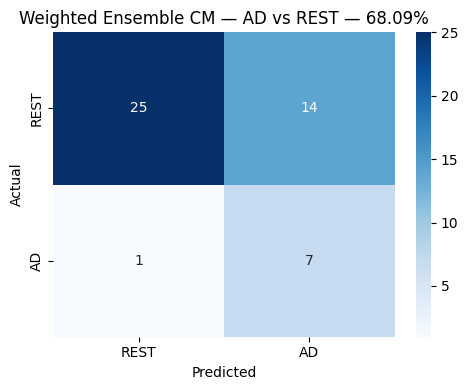


  CN vs REST
    Fold 1: patient_val_acc=46.43%  weight=0.1438  threshold=0.38
    Fold 2: patient_val_acc=74.55%  weight=0.2309  threshold=0.46
    Fold 3: patient_val_acc=77.78%  weight=0.2409  threshold=0.49
    Fold 4: patient_val_acc=62.96%  weight=0.1950  threshold=0.38
    Fold 5: patient_val_acc=61.11%  weight=0.1893  threshold=0.30
    Ensemble threshold (weighted avg): 0.410



  Weighted Ensemble Test Acc (CN vs REST): 65.96%  [47 patients]
              precision    recall  f1-score   support

        REST       0.88      0.62      0.72        34
          CN       0.43      0.77      0.56        13

    accuracy                           0.66        47
   macro avg       0.65      0.69      0.64        47
weighted avg       0.75      0.66      0.68        47



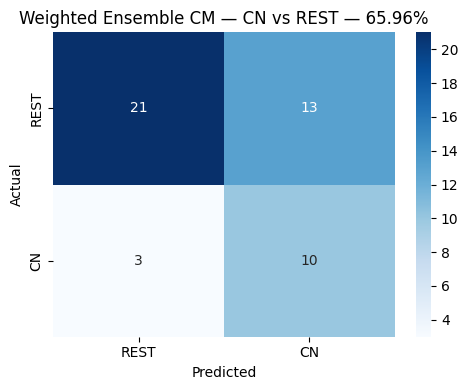


  MCI vs REST
    Fold 1: patient_val_acc=62.50%  weight=0.2147  threshold=0.45
    Fold 2: patient_val_acc=56.36%  weight=0.1936  threshold=0.05
    Fold 3: patient_val_acc=55.56%  weight=0.1909  threshold=0.05
    Fold 4: patient_val_acc=59.26%  weight=0.2036  threshold=0.42
    Fold 5: patient_val_acc=57.41%  weight=0.1972  threshold=0.38
    Ensemble threshold (weighted avg): 0.276


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



  Weighted Ensemble Test Acc (MCI vs REST): 55.32%  [47 patients]
              precision    recall  f1-score   support

        REST       0.00      0.00      0.00        21
         MCI       0.55      1.00      0.71        26

    accuracy                           0.55        47
   macro avg       0.28      0.50      0.36        47
weighted avg       0.31      0.55      0.39        47



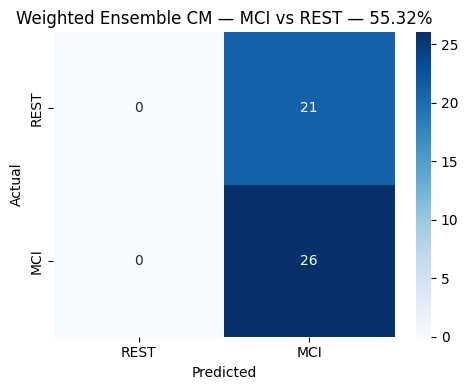

In [15]:
print("="*65)
print("  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)")
print("="*65)

final_results = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    test_bin = [(p, 1 if l == pos_class_idx else 0, pid) for p, l, pid in test_entries]
    test_ds = SliceDataset(test_bin, augment=False)
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=4, pin_memory=True, persistent_workers=True
    )

    fold_accs = np.array(fold_results[pos_name], dtype=np.float64)
    fold_weights = fold_accs / fold_accs.sum() if fold_accs.sum() > 0 else np.ones_like(fold_accs) / len(fold_accs)

    fold_thresholds = np.array(all_fold_thresholds[pos_name], dtype=np.float64)
    ensemble_thresh = float(np.sum(fold_weights * fold_thresholds))

    print(f"\n  {pos_name} vs REST")
    for fi, (acc, w, t) in enumerate(zip(fold_accs, fold_weights, fold_thresholds)):
        print(f"    Fold {fi+1}: patient_val_acc={acc*100:.2f}%  weight={w:.4f}  threshold={t:.2f}")
    print(f"    Ensemble threshold (weighted avg): {ensemble_thresh:.3f}")

    fold_models = all_fold_models[pos_name]
    for m in fold_models:
        m.to(device)
        m.eval()

    patient_probs = defaultdict(lambda: np.zeros(2, dtype=np.float64))
    patient_labels = {}

    with torch.no_grad():
        for images, labels, pids in tqdm(test_loader, desc=f"{pos_name} — Ensemble Eval", leave=False):
            images = images.to(device, non_blocking=True)
            batch_weighted_probs = np.zeros((images.size(0), 2), dtype=np.float64)

            for fold_model, w in zip(fold_models, fold_weights):
                with torch.amp.autocast(device_type="cuda" if device.type == 'cuda' else "cpu"):
                    logits = fold_model(images)
                probs = torch.softmax(logits, dim=1).cpu().numpy().astype(np.float64)
                batch_weighted_probs += w * probs

            for wp, label, pid in zip(batch_weighted_probs, labels.numpy(), pids):
                patient_probs[pid] += wp
                patient_labels[pid] = int(label)

    all_true, all_pred = [], []
    for pid, wp_sum in patient_probs.items():
        denom = float(wp_sum.sum())
        norm_pos_prob = float(wp_sum[1] / denom) if denom > 0 else 0.0
        pred_label = 1 if norm_pos_prob >= ensemble_thresh else 0
        all_true.append(patient_labels[pid])
        all_pred.append(pred_label)

    pat_acc = float(np.mean(np.array(all_true) == np.array(all_pred))) if all_true else 0.0
    print(f"\n  Weighted Ensemble Test Acc ({pos_name} vs REST): {pat_acc*100:.2f}%  [{len(patient_probs)} patients]")
    print(classification_report(all_true, all_pred, target_names=["REST", pos_name]))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["REST", pos_name], yticklabels=["REST", pos_name])
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Weighted Ensemble CM — {pos_name} vs REST — {pat_acc*100:.2f}%")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"cm_ensemble_{pos_name}_vs_rest.png"), dpi=150)
    plt.show()

    final_results[pos_name] = {
        "patient_test_acc": pat_acc,
        "cv_mean_acc": float(np.mean(fold_accs)) if fold_accs.size else 0.0,
        "cv_std_acc": float(np.std(fold_accs)) if fold_accs.size else 0.0,
        "fold_weights": fold_weights.tolist(),
        "fold_thresholds": fold_thresholds.tolist(),
        "ensemble_thresh": ensemble_thresh,
    }

    for m in fold_models:
        m.to("cpu")
    torch.cuda.empty_cache()

In [18]:
print("\n" + "="*65)
print("  FINAL SUMMARY — EFFICIENTNET-B0 + PATIENT-ID CV + SLICE VOTING")
print("="*65)
print(f"  {'Class':<8} {'CV patient acc (mean±std)':<28} {'Ensemble test (patient)':<24} {'Threshold'}")
print(f"  {'-'*70}")

for cls, res in final_results.items():
    cv_str = f"{res['cv_mean_acc']*100:.2f}% ± {res['cv_std_acc']*100:.2f}%"
    test_str = f"{res['patient_test_acc']*100:.2f}%"
    thr_str = f"{res['ensemble_thresh']:.3f}"
    print(f"  {cls:<8} {cv_str:<24} {test_str:<20} {thr_str}")

csv_path = os.path.join(CKPT_DIR, "results_weighted_ensemble_effnet.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "class", "cv_mean_acc_%", "cv_std_%", "ensemble_test_acc_%",
        "ensemble_threshold", "fold_weights", "fold_thresholds"
    ])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({
            "class": cls,
            "cv_mean_acc_%": round(res["cv_mean_acc"] * 100, 2),
            "cv_std_%": round(res["cv_std_acc"] * 100, 2),
            "ensemble_test_acc_%": round(res["patient_test_acc"] * 100, 2),
            "ensemble_threshold": round(res["ensemble_thresh"], 3),
            "fold_weights": str([round(w, 4) for w in res["fold_weights"]]),
            "fold_thresholds": str([round(t, 2) for t in res["fold_thresholds"]]),
        })

print(f"\nResults saved -> {csv_path}")


  FINAL SUMMARY — EFFICIENTNET-B0 + PATIENT-ID CV + SLICE VOTING
  Class    CV patient acc (mean±std)    Ensemble test (patient)  Threshold
  ----------------------------------------------------------------------
  AD       68.45% ± 3.52%           68.09%               0.268
  CN       64.57% ± 11.11%          65.96%               0.410
  MCI      58.22% ± 2.47%           55.32%               0.276

Results saved -> /kaggle/working/checkpoints_effnet/results_weighted_ensemble_effnet.csv


## 5. Explainable AI on the EfficientNet-B0 ensemble

Each `CLASS_NAMES[i] vs REST` binary head from fold-0 is probed with four complementary techniques: Grad-CAM (last conv block), LIME, SHAP (GradientExplainer), and Integrated Gradients. We use a fresh sample per class from the held-out `test_entries`.

In [ ]:
!pip install grad-cam lime shap -q

In [ ]:
import torch, torch.nn as nn, numpy as np, cv2, shap
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

def _denorm_eff(t):
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
    a = t.detach().cpu().numpy()
    if a.ndim == 4: a = a[0]
    return np.clip(np.transpose(a * std + mean, (1, 2, 0)), 0, 1)

xai_eff = {}
for path, label, pid in test_entries:
    if label not in xai_eff:
        base = os.path.splitext(os.path.basename(path))[0]
        key  = f'{pid}_{base}'
        pt_path = pt_lookup.get(key)
        if pt_path is None: continue
        tensor = torch.load(pt_path, weights_only=True).float() / 255.0
        tensor = normalize(tensor).unsqueeze(0).to(device)
        xai_eff[label] = tensor
    if len(xai_eff) == len(CLASS_NAMES): break
print('XAI tensors collected for:', [CLASS_NAMES[k] for k in sorted(xai_eff)])


### 5.1 Grad-CAM

In [ ]:
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    if cls_idx not in xai_eff: continue
    fold_model = all_fold_models[cls_name][0].to(device).eval()
    img_t = xai_eff[cls_idx]
    target_layer = fold_model.features[-1]
    cam = GradCAM(model=fold_model, target_layers=[target_layer])
    grayscale = cam(input_tensor=img_t, targets=[ClassifierOutputTarget(1)])[0]
    img_rgb = _denorm_eff(img_t)
    heat = cv2.applyColorMap((grayscale * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB) / 255.0
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    ax[0].imshow(img_rgb); ax[0].set_title(f'Input ({cls_name})'); ax[0].axis('off')
    ax[1].imshow(grayscale, cmap='hot'); ax[1].set_title('Grad-CAM'); ax[1].axis('off')
    ax[2].imshow(0.5 * img_rgb + 0.5 * heat); ax[2].set_title('Overlay'); ax[2].axis('off')
    plt.suptitle(f'Grad-CAM — {cls_name} vs REST'); plt.tight_layout(); plt.show()
    fold_model.to('cpu'); torch.cuda.empty_cache()


### 5.2 LIME

In [ ]:
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    if cls_idx not in xai_eff: continue
    fold_model = all_fold_models[cls_name][0].to(device).eval()
    img_t = xai_eff[cls_idx]
    img_rgb = _denorm_eff(img_t)
    def lime_predict_fn(images_np, _m=fold_model):
        imgs = torch.from_numpy(images_np).float().permute(0, 3, 1, 2).to(device)
        mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
        std  = torch.tensor(IMAGENET_STD,  device=device).view(1, 3, 1, 1)
        imgs = (imgs - mean) / std
        with torch.no_grad():
            return torch.softmax(_m(imgs), dim=1).cpu().numpy()
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image=img_rgb, classifier_fn=lime_predict_fn,
        labels=[1], num_samples=500
    )
    img, mask = explanation.get_image_and_mask(label=1, positive_only=False,
                                               num_features=8, hide_rest=False)
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    ax[0].imshow(img_rgb); ax[0].set_title(f'Input ({cls_name})'); ax[0].axis('off')
    ax[1].imshow(mark_boundaries(img, mask)); ax[1].set_title('LIME'); ax[1].axis('off')
    plt.suptitle(f'LIME — {cls_name} vs REST'); plt.tight_layout(); plt.show()
    fold_model.to('cpu'); torch.cuda.empty_cache()


### 5.3 SHAP (GradientExplainer)

In [ ]:
bg_tensors = []
for path, label, pid in test_entries:
    base = os.path.splitext(os.path.basename(path))[0]
    key = f'{pid}_{base}'
    pt = pt_lookup.get(key)
    if pt is None: continue
    t = torch.load(pt, weights_only=True).float() / 255.0
    bg_tensors.append(normalize(t))
    if len(bg_tensors) >= 16: break
bg = torch.stack(bg_tensors, dim=0).to(device)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    if cls_idx not in xai_eff: continue
    fold_model = all_fold_models[cls_name][0].to(device).eval()
    img_t = xai_eff[cls_idx]
    sv = shap.GradientExplainer(fold_model, bg).shap_values(img_t)
    smap = np.asarray(sv[1][0] if isinstance(sv, list) else sv[0])
    if smap.ndim == 4: smap = smap[0]
    imp = smap.sum(axis=0)
    img_rgb = _denorm_eff(img_t)
    H, W = img_rgb.shape[:2]
    imp = cv2.resize(imp.astype(np.float32), (W, H), interpolation=cv2.INTER_LINEAR)
    vmax = np.abs(imp).max() + 1e-8
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    ax[0].imshow(img_rgb); ax[0].set_title(f'Input ({cls_name})'); ax[0].axis('off')
    ax[1].imshow(img_rgb)
    over = ax[1].imshow(imp, cmap='coolwarm', alpha=0.5, vmin=-vmax, vmax=vmax)
    ax[1].set_title('SHAP attributions'); ax[1].axis('off')
    plt.colorbar(over, ax=ax[1], fraction=0.046, pad=0.04)
    plt.suptitle(f'SHAP — {cls_name} vs REST'); plt.tight_layout(); plt.show()
    fold_model.to('cpu'); torch.cuda.empty_cache()


### 5.4 Integrated Gradients

In [ ]:
def integrated_gradients_eff(m, img_tensor, target_class, steps=50):
    m.eval()
    x = img_tensor.to(device)
    baseline = torch.zeros_like(x)
    grads = torch.zeros_like(x)
    for a in torch.linspace(0.0, 1.0, steps).to(device):
        xi = (baseline + a * (x - baseline)).detach().requires_grad_(True)
        score = m(xi)[0, target_class]
        g = torch.autograd.grad(score, xi)[0]
        grads = grads + g.detach()
    ig = (x - baseline) * (grads / steps)
    return ig.detach().cpu().numpy()[0]

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    if cls_idx not in xai_eff: continue
    fold_model = all_fold_models[cls_name][0].to(device).eval()
    img_t = xai_eff[cls_idx]
    ig_map = integrated_gradients_eff(fold_model, img_t, 1, steps=50)
    attr = ig_map.sum(axis=0)
    img_rgb = _denorm_eff(img_t)
    vmax = np.abs(attr).max() + 1e-8
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    ax[0].imshow(img_rgb); ax[0].set_title(f'Input ({cls_name})'); ax[0].axis('off')
    im = ax[1].imshow(attr, cmap='seismic', vmin=-vmax, vmax=vmax)
    ax[1].set_title('IG attributions'); ax[1].axis('off')
    plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    ax[2].imshow(img_rgb)
    ax[2].imshow(attr, cmap='seismic', vmin=-vmax, vmax=vmax, alpha=0.5)
    ax[2].set_title('Overlay'); ax[2].axis('off')
    plt.suptitle(f'Integrated Gradients — {cls_name} vs REST'); plt.tight_layout(); plt.show()
    fold_model.to('cpu'); torch.cuda.empty_cache()
